#Imports & Data Init

In [4]:
import random
import math
import matplotlib.pyplot as plt
# Depot
depot = (0, 0)

# Customers
customers = {
    1: (2, 3),
    2: (5, 4),
    3: (1, 7),
    4: (6, 8),
    5: (3, 6)
}

num_vehicles = 2

#Distanace Function

In [5]:
def distance(p1, p2):
    return math.sqrt((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2)

#Genotype → Routes

In [6]:
def decode(chromosome):
    routes = [[] for _ in range(num_vehicles)]
    for i, customer in enumerate(chromosome):
        routes[i % num_vehicles].append(customer)
    return routes

#Fitness Function

In [7]:
def fitness(chromosome):
    routes = decode(chromosome)
    total_distance = 0

    for route in routes:
        if not route:
            continue

        prev = depot

        for cust in route:
            total_distance += distance(prev, customers[cust])
            prev = customers[cust]

        total_distance += distance(prev, depot)

    return 1 / total_distance

#Population


In [8]:
def create_individual():
    individual = list(customers.keys())
    random.shuffle(individual)
    return individual

def create_population(size):
    return [create_individual() for _ in range(size)]

#Selection

In [9]:
def selection(population):
    return random.choice(population)

#Crossover

In [10]:
def crossover(p1, p2):
    size = len(p1)
    start, end = sorted(random.sample(range(size), 2))

    child = [None]*size
    child[start:end] = p1[start:end]

    fill = [x for x in p2 if x not in child]

    j = 0
    for i in range(size):
        if child[i] is None:
            child[i] = fill[j]
            j += 1

    return child

#Mutation

In [11]:
def mutate(individual, rate=0.1):
    if random.random() < rate:
        i, j = random.sample(range(len(individual)), 2)
        individual[i], individual[j] = individual[j], individual[i]
    return individual

#Genetic Algorithm

In [12]:
def genetic_algorithm(generations=100, pop_size=20):
    population = create_population(pop_size)
    best = None

    for gen in range(generations):
        new_population = []

        for _ in range(pop_size):
            p1 = selection(population)
            p2 = selection(population)

            child = crossover(p1, p2)
            child = mutate(child)

            new_population.append(child)

        population = new_population

        best = max(population, key=fitness)
        print(f"Gen {gen}: Best Distance = {1/fitness(best):.2f}")

    return best

In [13]:
best_solution = genetic_algorithm()

routes = decode(best_solution)

print("\nBest Routes:")
for i, route in enumerate(routes):
    print(f"Vehicle {i+1}: {route}")

Gen 0: Best Distance = 36.08
Gen 1: Best Distance = 36.08
Gen 2: Best Distance = 35.64
Gen 3: Best Distance = 35.65
Gen 4: Best Distance = 36.08
Gen 5: Best Distance = 36.08
Gen 6: Best Distance = 36.08
Gen 7: Best Distance = 36.08
Gen 8: Best Distance = 35.65
Gen 9: Best Distance = 35.65
Gen 10: Best Distance = 35.65
Gen 11: Best Distance = 35.65
Gen 12: Best Distance = 35.65
Gen 13: Best Distance = 36.08
Gen 14: Best Distance = 35.64
Gen 15: Best Distance = 35.64
Gen 16: Best Distance = 36.60
Gen 17: Best Distance = 36.60
Gen 18: Best Distance = 36.55
Gen 19: Best Distance = 36.08
Gen 20: Best Distance = 35.65
Gen 21: Best Distance = 36.08
Gen 22: Best Distance = 35.64
Gen 23: Best Distance = 35.64
Gen 24: Best Distance = 36.08
Gen 25: Best Distance = 36.08
Gen 26: Best Distance = 36.91
Gen 27: Best Distance = 36.08
Gen 28: Best Distance = 36.08
Gen 29: Best Distance = 36.08
Gen 30: Best Distance = 36.08
Gen 31: Best Distance = 36.91
Gen 32: Best Distance = 36.91
Gen 33: Best Distanc

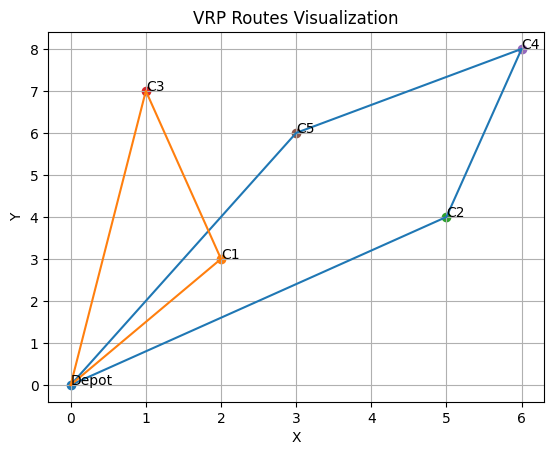

In [14]:
def plot_routes(routes):
    plt.figure()

    # Depot
    plt.scatter(*depot)
    plt.text(*depot, "Depot")

    # Customers
    for cid, (x, y) in customers.items():
        plt.scatter(x, y)
        plt.text(x, y, f"C{cid}")

    # Routes
    for route in routes:
        x_coords = [depot[0]]
        y_coords = [depot[1]]

        for c in route:
            x_coords.append(customers[c][0])
            y_coords.append(customers[c][1])

        x_coords.append(depot[0])
        y_coords.append(depot[1])

        plt.plot(x_coords, y_coords)

    plt.title("VRP Routes Visualization")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.grid()
    plt.show()

plot_routes(routes)